In [1]:
import pandas as pd
import numpy as np

In [2]:
filepath = "../Raw/WEF_GCI_WIDEF.csv"
df = pd.read_csv(filepath)
df

,FREQ,FREQ_LABEL,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,UNIT_MEASURE,UNIT_MEASURE_LABEL,DATABASE_ID,DATABASE_ID_LABEL,UNIT_MULT,UNIT_MULT_LABEL,OBS_STATUS,OBS_STATUS_LABEL,OBS_CONF,OBS_CONF_LABEL,2017,2018,2019
0,A,Annual,AGO,Angola,WEF_GCI_AIRINF,GCI 4.0: Air,0_TO_100,0-100 scale,WEF_GCI,Global Competitiveness Index (GCI) 4.0,0,Units,A,Normal value,PU,Public,NaN,32.23,32.53
1,A,Annual,AGO,Angola,WEF_GCI_AIRINF,GCI 4.0: Air,RANK,Rank,WEF_GCI,Global Competitiveness Index (GCI) 4.0,0,Units,A,Normal value,PU,Public,NaN,118.00,120.00
2,A,Annual,AGO,Angola,WEF_GCI_BANKCAPRWA,GCI 4.0: Banks' regulatory capital ratio (% of...,PT_AS_RKWT,Percentage of risk-weighted assets,WEF_GCI,Global Competitiveness Index (GCI) 4.0,0,Units,A,Normal value,PU,Public,NaN,NaN,18.04
3,A,Annual,AGO,Angola,WEF_GCI_BANKCAPRWA,GCI 4.0: Banks' regulatory capital ratio (% of...,RANK,Rank,WEF_GCI,Global Competitiveness Index (GCI) 4.0,0,Units,A,Normal value,PU,Public,NaN,NaN,54.00
4,A,Annual,AGO,Angola,WEF_GCI_BANKCAPRWA,GCI 4.0: Banks' regulatory capital ratio (% of...,SCORE,Score,WEF_GCI,Global Competitiveness Index (GCI) 4.0,0,Units,A,Normal value,PU,Public,100.00,100.00,100.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60526,A,Annual,ZWE,Zimbabwe,WEF_GCI_WATERINF,GCI 4.0: Water,0_TO_100,0-100 scale,WEF_GCI,Global Competitiveness Index (GCI) 4.0,0,Units,A,Normal value,PU,Public,43.24,43.99,27.79
60527,A,Annual,ZWE,Zimbabwe,WEF_GCI_WATERINF,GCI 4.0: Water,RANK,Rank,WEF_GCI,Global Competitiveness Index (GCI) 4.0,0,Units,A,Normal value,PU,Public,125.00,128.00,132.00
60528,A,Annual,ZWE,Zimbabwe,WEF_GCI_WORKRIGHT,"GCI 4.0: Workers' Rights Index (0-100, best)",0_TO_100,0-100 scale,WEF_GCI,Global Competitiveness Index (GCI) 4.0,0,Units,A,Normal value,PU,Public,60.82,62.89,57.00
60529,A,Annual,ZWE,Zimbabwe,WEF_GCI_WORKRIGHT,"GCI 4.0: Workers' Rights Index (0-100, best)",RANK,Rank,WEF_GCI,Global Competitiveness Index (GCI) 4.0,0,Units,A,Normal value,PU,Public,94.00,92.00,113.00


In [ ]:
yr_cols = [col for col in df.columns if col.startswith("19") or col.startswith("20")]
yr_cols = [col for col in yr_cols if len(col) == 4]
yr_cols

['2017', '2018', '2019']

In [4]:
df["INDICATOR_LABEL"].value_counts()

INDICATOR_LABEL
GCI 4.0: Banks' regulatory capital ratio (% of risk-weighted assets)         423
GCI 4.0: Fixed-broadband internet subscriptions (per 100 pop.)               423
GCI 4.0: Extent of conflict of interest regulation (0-10, best)              423
GCI 4.0: Efficiency of legal framework in challenging regulations (1-7)      423
GCI 4.0: Electrification rate (% of population)                              423
                                                                            ... 
GCI 4.0: Fibre-to-the-home/building Internet subscriptions (per 100 pop.)    260
GCI 4.0: Sea                                                                 216
GCI 4.0: Change in government debt                                           141
GCI 4.0: Government debt to GDP                                              141
GCI 4.0: Country bond ratings                                                125
Name: count, Length: 168, dtype: int64

In [5]:

# Selected indicators: trade, investment, governance, business effectiveness
SELECTED_INDICATORS = [
    'WEF_GCI_GCI4',            # Overall GCI score
    'WEF_GCI_GCI4_C_07_02',    # Trade openness
    # 'WEF_GCI_GCI4_C_07_01',    # Domestic competition
    # 'WEF_GCI_GCI4_C_07',       # Product market (composite)
    # 'WEF_GCI_IATACONNECTIDX',  # Airport connectivity
    # 'WEF_GCI_LINERSHIPIDX',    # Liner Shipping Connectivity
    'WEF_GCI_GCI4_C_09',       # Financial system (composite)
    'WEF_GCI_GCI4_C_09_01',    # Financial depth
    'WEF_GCI_GCI4_C_09_02',    # Financial stability
    # 'WEF_GCI_INVCOMMERC',      # Commercialization
    # 'WEF_GCI_GCI4_C_10',       # Market size
    # 'WEF_GCI_RESEARCH',        # R&D
    # 'WEF_GCI_GCI4_A_01',       # Institutions (composite)
    # 'WEF_GCI_GCI4_A_01_03',    # Checks and balances
    # 'WEF_GCI_GCI4_A_01_04',    # Public-sector performance
    # 'WEF_GCI_GCI4_A_01_05',    # Transparency
    # 'WEF_GCI_GCI4_A_01_06',    # Property rights
    # 'WEF_GCI_GCI4_A_01_07',    # Corporate governance
    'WEF_GCI_TRANSPARENCYCPI', # Corruption Perception Index
    # 'WEF_GCI_GCI4_D_11',       # Business dynamism (composite)
    # 'WEF_GCI_GCI4_D_11_01',    # Administrative requirements
    # 'WEF_GCI_GCI4_D_11_02',    # Entrepreneurial culture
    # 'WEF_GCI_GCI4_D_12',       # Innovation capability
]

# Keep only 0-100 score rows (drop rank rows) and selected indicators
df_filtered = df[
    (df['UNIT_MEASURE'] == '0_TO_100') &
    (df['INDICATOR'].isin(SELECTED_INDICATORS))
].copy()

# Melt year columns into long format
df_long = df_filtered.melt(
    id_vars=['REF_AREA', 'INDICATOR', 'INDICATOR_LABEL'],
    value_vars=yr_cols,
    var_name='YEAR',
    value_name='VALUE'
)

# Clean up
df_long['YEAR'] = df_long['YEAR'].astype(int)
df_long = df_long.dropna(subset=['VALUE']).reset_index(drop=True)
df_long = df_long.sort_values(['REF_AREA', 'INDICATOR', 'YEAR']).reset_index(drop=True)

df_long

,REF_AREA,INDICATOR,INDICATOR_LABEL,YEAR,VALUE
0,AGO,WEF_GCI_GCI4,GCI 4.0: Global Competitiveness Index 4.0,2018,37.06
1,AGO,WEF_GCI_GCI4,GCI 4.0: Global Competitiveness Index 4.0,2019,38.11
2,AGO,WEF_GCI_GCI4_C_07_02,GCI 4.0: Trade openness,2018,48.20
3,AGO,WEF_GCI_GCI4_C_07_02,GCI 4.0: Trade openness,2019,45.46
4,AGO,WEF_GCI_GCI4_C_09,GCI 4.0: 9th pillar: Financial system,2018,40.05
...,...,...,...,...,...
2468,ZWE,WEF_GCI_GCI4_C_09_02,GCI 4.0: Stability,2018,81.15
2469,ZWE,WEF_GCI_GCI4_C_09_02,GCI 4.0: Stability,2019,81.69
2470,ZWE,WEF_GCI_TRANSPARENCYCPI,GCI 4.0: Corruption Perception Index (0=highly...,2017,22.00
2471,ZWE,WEF_GCI_TRANSPARENCYCPI,GCI 4.0: Corruption Perception Index (0=highly...,2018,22.00


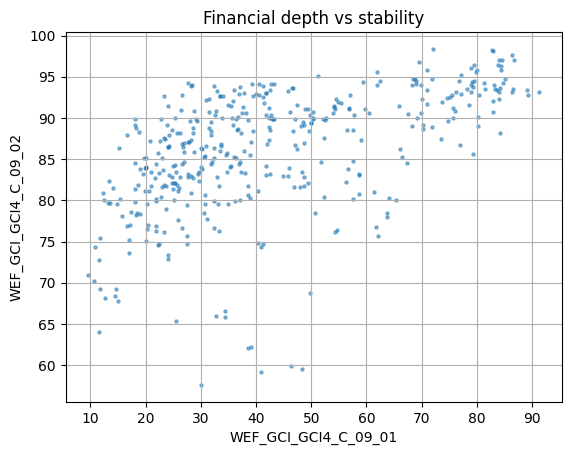

INDICATOR,WEF_GCI_GCI4_C_09_01,WEF_GCI_GCI4_C_09_02
INDICATOR,,
WEF_GCI_GCI4_C_09_01,1.000000,0.536386
WEF_GCI_GCI4_C_09_02,0.536386,1.000000


In [8]:
# Plot indicators in financial composite
x = "WEF_GCI_GCI4_C_09_01"
y = "WEF_GCI_GCI4_C_09_02"

import matplotlib.pyplot as plt

# Get plot df
plot_df = df_long[df_long['INDICATOR'].isin([x, y])]
plot_df = plot_df.pivot_table(index=['REF_AREA', 'YEAR'], columns='INDICATOR', values='VALUE').reset_index()

plt.scatter(plot_df[x], plot_df[y], s=5, alpha=0.5)
plt.xlabel(x)
plt.ylabel(y)
plt.title("Financial depth vs stability")
plt.grid(True)
plt.show()

# Give me nan-corr of these
plot_df[[x, y]].corr()

In [9]:
df_long["INDICATOR"].value_counts()

INDICATOR
WEF_GCI_TRANSPARENCYCPI    413
WEF_GCI_GCI4               412
WEF_GCI_GCI4_C_07_02       412
WEF_GCI_GCI4_C_09          412
WEF_GCI_GCI4_C_09_01       412
WEF_GCI_GCI4_C_09_02       412
Name: count, dtype: int64

In [10]:
INDICATOR_RENAME = {
    "WEF_GCI_GCI4":            "gci_overall",
    "WEF_GCI_TRANSPARENCYCPI": "gci_corruption",
    "WEF_GCI_GCI4_C_07_02":    "gci_trade_openness",
    "WEF_GCI_GCI4_C_09":       "gci_financial_composite",
    "WEF_GCI_GCI4_C_09_01":    "gci_financial_depth",
    "WEF_GCI_GCI4_C_09_02":    "gci_financial_stability",
}

df_long['INDICATOR'] = df_long['INDICATOR'].map(INDICATOR_RENAME)
df_long

,REF_AREA,INDICATOR,INDICATOR_LABEL,YEAR,VALUE
0,AGO,gci_overall,GCI 4.0: Global Competitiveness Index 4.0,2018,37.06
1,AGO,gci_overall,GCI 4.0: Global Competitiveness Index 4.0,2019,38.11
2,AGO,gci_trade_openness,GCI 4.0: Trade openness,2018,48.20
3,AGO,gci_trade_openness,GCI 4.0: Trade openness,2019,45.46
4,AGO,gci_financial_composite,GCI 4.0: 9th pillar: Financial system,2018,40.05
...,...,...,...,...,...
2468,ZWE,gci_financial_stability,GCI 4.0: Stability,2018,81.15
2469,ZWE,gci_financial_stability,GCI 4.0: Stability,2019,81.69
2470,ZWE,gci_corruption,GCI 4.0: Corruption Perception Index (0=highly...,2017,22.00
2471,ZWE,gci_corruption,GCI 4.0: Corruption Perception Index (0=highly...,2018,22.00


In [11]:
df_long = df_long.rename(columns={"REF_AREA": "iso3", "YEAR": "year", "VALUE": "value"})

df_long = df_long[["iso3", "year", "INDICATOR", "value"]]
df_long

,iso3,year,INDICATOR,value
0,AGO,2018,gci_overall,37.06
1,AGO,2019,gci_overall,38.11
2,AGO,2018,gci_trade_openness,48.20
3,AGO,2019,gci_trade_openness,45.46
4,AGO,2018,gci_financial_composite,40.05
...,...,...,...,...
2468,ZWE,2018,gci_financial_stability,81.15
2469,ZWE,2019,gci_financial_stability,81.69
2470,ZWE,2017,gci_corruption,22.00
2471,ZWE,2018,gci_corruption,22.00


In [12]:
# Now, expand so the INDICATOR values becomes separate columns with the corresponding values and years
df_wide = df_long.pivot_table(index=['iso3', 'year'], columns='INDICATOR', values='value').reset_index()
df_wide = df_wide.reset_index(drop=True)
df_wide

INDICATOR,iso3,year,gci_corruption,gci_financial_composite,gci_financial_depth,gci_financial_stability,gci_overall,gci_trade_openness
0,AGO,2017,18.0,NaN,NaN,NaN,NaN,NaN
1,AGO,2018,19.0,40.05,11.74,75.44,37.06,48.20
2,AGO,2019,19.0,38.42,14.95,67.77,38.11,45.46
3,ALB,2017,39.0,50.53,25.31,82.06,57.29,65.64
4,ALB,2018,38.0,51.33,25.04,84.19,58.10,68.14
...,...,...,...,...,...,...,...,...
412,ZMB,2018,37.0,48.34,19.90,83.89,46.05,55.53
413,ZMB,2019,35.0,47.84,19.54,83.20,46.51,51.52
414,ZWE,2017,22.0,50.67,25.69,81.89,42.01,34.27
415,ZWE,2018,22.0,50.45,25.88,81.15,42.61,33.28


In [13]:
df_wide.to_csv("../Clean/WEF_GCI.csv", index=False)